# 7. Model Comparision - Validation F1 Macro--------------------------------------

                    F1_Macro_Val
SMOTE + RF              0.925602
Cost-Sensitive RF       0.917375
Cost-Sensitive DT       0.893849
SMOTE + DT              0.893796
Balanced RF             0.726962
Cost-Sensitive XGB      0.009171
SMOTE + XGB             0.007324


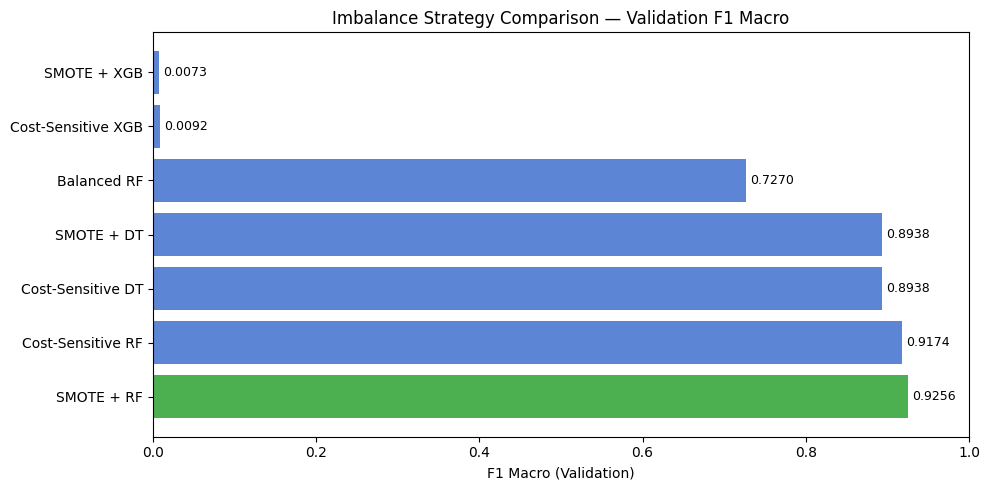


Best model: SMOTE + RF (F1 Macro = 0.9256)


In [ ]:
# Collect validation F1 Macro scores
results = {}

# setup some helpers that helps handle XGB 0-indexed offset
def get_f1(model, X_eval, y_eval, offset=0):
    pred = model.predict(X_eval)
    if offset:
        pred = pred + offset
    return f1_score(y_eval, pred, average='macro')

results['SMOTE + DT']         = get_f1(smote_dt_best,  X_val, y_val)
results['SMOTE + RF']         = get_f1(smote_rf_best,  X_val, y_val)
results['SMOTE + XGB']        = get_f1(smote_xgb_best, X_val, y_val_adj, offset=1)
results['Balanced RF']        = get_f1(brf_best,        X_val, y_val)
results['Cost-Sensitive DT']  = get_f1(cs_dt_best,     X_val, y_val)
results['Cost-Sensitive XGB'] = get_f1(cs_xgb_best,    X_val, y_val_adj, offset=1)
results['Cost-Sensitive RF']  = get_f1(cs_rf_best,     X_val, y_val)

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1_Macro_Val'])
results_df = results_df.sort_values('F1_Macro_Val', ascending=False)
print(results_df.to_string())

# Bar chart visualization for Macro F1 Validation
plt.figure(figsize=(10, 5))
colors = ['#4CAF50' if v == results_df['F1_Macro_Val'].max() else '#5C85D6'
          for v in results_df['F1_Macro_Val']]
bars = plt.barh(results_df.index, results_df['F1_Macro_Val'], color=colors)
plt.xlabel('F1 Macro (Validation)')
plt.title('Imbalance Strategy Comparison — Validation F1 Macro')
plt.xlim(0, 1)
for bar, val in zip(bars, results_df['F1_Macro_Val']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
print(f'\nBest model: {best_model_name} (F1 Macro = {results_df.iloc[0,0]:.4f})')

# 8. Final Test Evaluation for Best Model Only

 SMOTE + RF — FINAL TEST SET
              precision    recall  f1-score   support

           1      0.961     0.941     0.951     42368
           2      0.955     0.962     0.959     56661
           3      0.932     0.960     0.946      7151
           4      0.876     0.891     0.883       549
           5      0.874     0.897     0.885      1899
           6      0.888     0.922     0.905      3473
           7      0.951     0.966     0.959      4102

    accuracy                          0.952    116203
   macro avg      0.920     0.934     0.927    116203
weighted avg      0.952     0.952     0.952    116203

Accuracy : 0.9517
F1 Macro : 0.9267


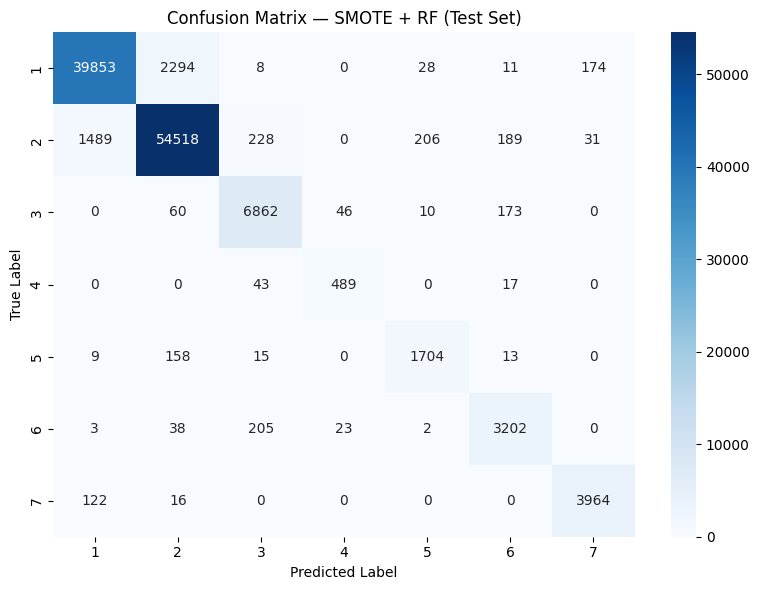

In [ ]:
# Transfer map model name to estimator
model_map = {
    'SMOTE + DT':         (smote_dt_best,  0),
    'SMOTE + RF':         (smote_rf_best,  0),
    'SMOTE + XGB':        (smote_xgb_best, 1),
    'Balanced RF':        (brf_best,        0),
    'Cost-Sensitive DT':  (cs_dt_best,     0),
    'Cost-Sensitive XGB': (cs_xgb_best,    1),
    'Cost-Sensitive RF':  (cs_rf_best,     0)
}

best_est, offset = model_map[best_model_name]
y_test_input = y_test - 1 if offset else y_test

y_test_pred = best_est.predict(X_test)
if offset:
    y_test_pred = y_test_pred + 1

print(f' {best_model_name} — FINAL TEST SET')
print(classification_report(y_test, y_test_pred, digits=3))
print(f'Accuracy : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'F1 Macro : {f1_score(y_test, y_test_pred, average="macro"):.4f}')

# Confusion matrix heatmap load out
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1,8), yticklabels=range(1,8))
plt.title(f'Confusion Matrix — {best_model_name} (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()